# Loss Functions for Machine Learning

This notebook outlines how `scores` can be used to provide `loss` functions for machine learning objective functions, and `evals` which can be used to evaluate a machine learning model but cannot be optimised in the same sense that a loss function can be optimised.

## Caveats and Important Information

Scores achieves this by providing an alternative, array-only interface to many of its functions. These functions share implementation details with the `xarray` modules, but use numerical indexing only and do not support dimension labelling. Array-based interfaces (i.e., numpy-compatible interfaces) are the standard data structure for loss function calculations, and this approach provides the widest possible range of supported integrations. 

At the time of writing, the README at [https://github.com/data-apis/array-api-compat](https://github.com/data-apis/array-api-compat) indicates that the following array types may be supported: NumPy, CuPy, PyTorch, Dask, JAX, ndonnx and sparse. Testing has been performed against NumPy and PyTorch.

Loss function capability in `scores` is still under development. In order to provide access to some functionality early, an iterative approach to the development is being taken. This means that not all functionality (for example, reducing and preserving dimensions, or weighting the results) may be supported. Only a few functions will initially be implemented, to allow proper time for testing, and approach more complex functions carefully to ensure there are no regressions or incompatibilities.

## Example

For this example, we are going to use a standard dataset which is included directly in the scikit-learn library, and train a neural network using the PyTorch framework. For more complex machine learning examples using weather data, please see the [PyEarthTools](pyearthtools.readthedocs.io) framework, a machine learning framework designed for that purpose. For this notebook, the goal is to demonstrate the technical side of integrating `scores` with standard machine learning frameworks.

We thank https://machinelearningmastery.com/building-a-regression-model-in-pytorch/ for providing the inspiration for this example. 

In [1]:
import plotly.express as px
import scores
import sklearn
import torch

### Loss Function Information

The loss function API provided by `scores` will by default produce a compatible result for most standard machine learning examples - i.e. a single number. It would be possible to use some of the more advanced options in `scores` such as dimensional preservation if that was wanted, but it will complicate the example. Suggestions for possible extensions are included at the end of this tutorial.

In [2]:
# Loss function is provided by `scores` 
loss_fn = scores.loss.mse  # mean square error

### Running on the GPU

The goal for `scores` is not just to support the tensor data types, but to run correctly on the GPU. There are a number of libraries which support the tensor datatype, 
but copy the data back from the GPU to the system RAM in orded to perform CPU-based calculation. While this example can be run quickly on a CPU due to its small size,
we make sure to copy the data into a GPU device to ensure the design is working as intended. The code below will use a CUDA-compatible GPU if available; the 'mps' device on MacOS if available, and fall back to the CPU if no GPU devices of these kind are found. 

In [3]:
## Set the backend automatically
device = 'cpu'  # Default, should work everywhere
if torch.backends.mps.is_available():
    device = 'mps'  # Will only work on macos
if torch.cuda.device_count() > 0:
    device = 'gpu'  # Will only work if a CUDA compatible GPU is found

print(device)

mps


### Data Fetching

In [4]:
data = sklearn.datasets.fetch_california_housing()
X, y = data.data, data.target

In [5]:
# Define the model
model = torch.nn.Sequential(
    torch.nn.Linear(8, 24),   # This is set for the given input size
    torch.nn.ReLU(),          # Feel free to change this
    torch.nn.Linear(24, 12),  # Feel free to change this
    torch.nn.ReLU(),          # Feel free to change this
    torch.nn.Linear(12, 6),   # Feel free to change this# Feel free to change this
    torch.nn.ReLU(),          # Feel free to change this
    torch.nn.Linear(6, 1)     # The required output for this example is a single number
).to(device)

In [6]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
# Set up a test/train split in the data

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1).to(device)

# Training loop configuration

n_epochs = 4    # number of epochs to run
batch_size = 6  # size of each batch
batch_start_indexes = torch.arange(0, len(X_train), batch_size)
epoch_score_history = []

In [8]:
# training loop
for epoch in range(n_epochs):
    print(f"Starting training for epoch: {epoch}")
    model.train()
    for start in batch_start_indexes:        
        # Use several samples (a batch) rather than a single sample
        # This is more efficient for small datasets, and may help regularise the network training
        # On very large data sets, batch sizes may need to be very small, or even one
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]

        # Use the model to make a prediction
        y_pred = model(X_batch)

        # Calculate the error, using the `scores` loss function
        loss = loss_fn(y_pred, y_batch)

        # Back-propagate the loss and update the optimizer
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse.detach())
    epoch_score_history.append(mse)

Starting training for epoch: 0
Starting training for epoch: 1
Starting training for epoch: 2
Starting training for epoch: 3


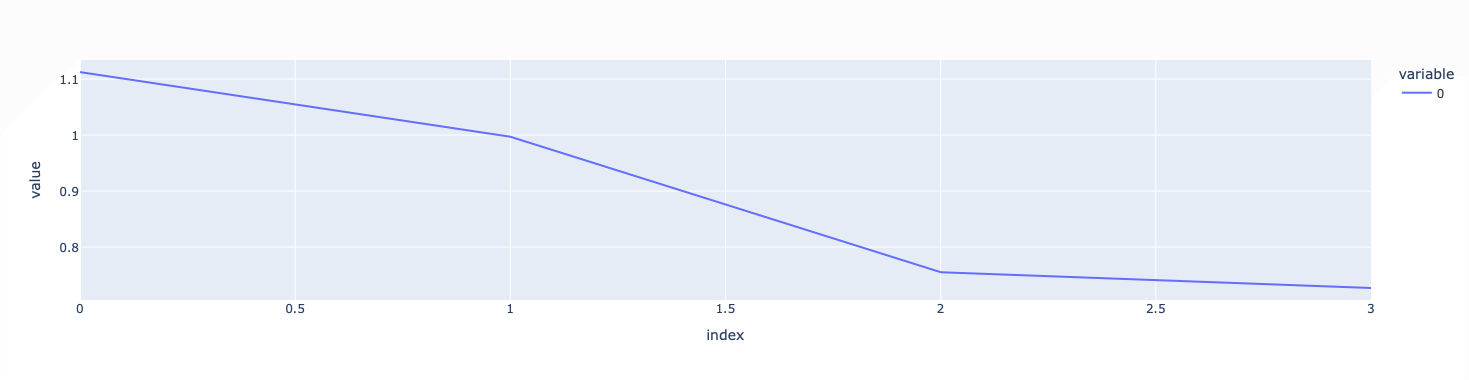

In [9]:
px.line(epoch_score_history)